In [1]:
%matplotlib ipympl

import os

# Set to a very large number (e.g., 2^40 or about 1 trillion pixels)
# The value must be passed as a string.
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = str(2**40)

import cv2
import numpy as np
import ezdxf
import matplotlib.pyplot as plt
import math
from metrology_lib import show_image, process_dxf, sort_grid, process_contours, calibrate_resolutions, save_top_width_error_subimages, create_clean_binary_mask

In [2]:
# --- Configuration ---
PATH = "F:/LEM-X/Masks/Metrology/"
IMAGE_PATH = PATH + "lato2_full_50x.bmp"
DXF_PATH =  PATH + "mask_050_1040x17_20260129_ELXDIM_250um_Kirana_sector_10x5cm.dxf"

MM_PER_PIXEL_X = 1/478.9437 #lato2_full_50x.bmp
MM_PER_PIXEL_Y = 1/478.9437 #lato2_full_50x.bmp
'''
--- Calibration Results ---
Initial Res X: 0.002087928 mm/px
Optimal Res X: 0.002088558 mm/px
Error X:       0.0302 %
-------------------------
Initial Res Y: 0.002087928 mm/px
Optimal Res Y: 0.002087800 mm/px
Error Y:       0.0061 
'''
MM_PER_PIXEL_X = 0.002088558 #lato2_full_50x.bmp
MM_PER_PIXEL_Y = 0.002087800 #lato2_full_50x.bmp

In [3]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img = cv2.flip(img, 0)
print(img.shape)
#img = cv2.rotate(img, cv2.ROTATE_180)

(24796, 48840)


In [4]:
#lato2_full_50x
subimg = img[500:-1000, 500:-500]

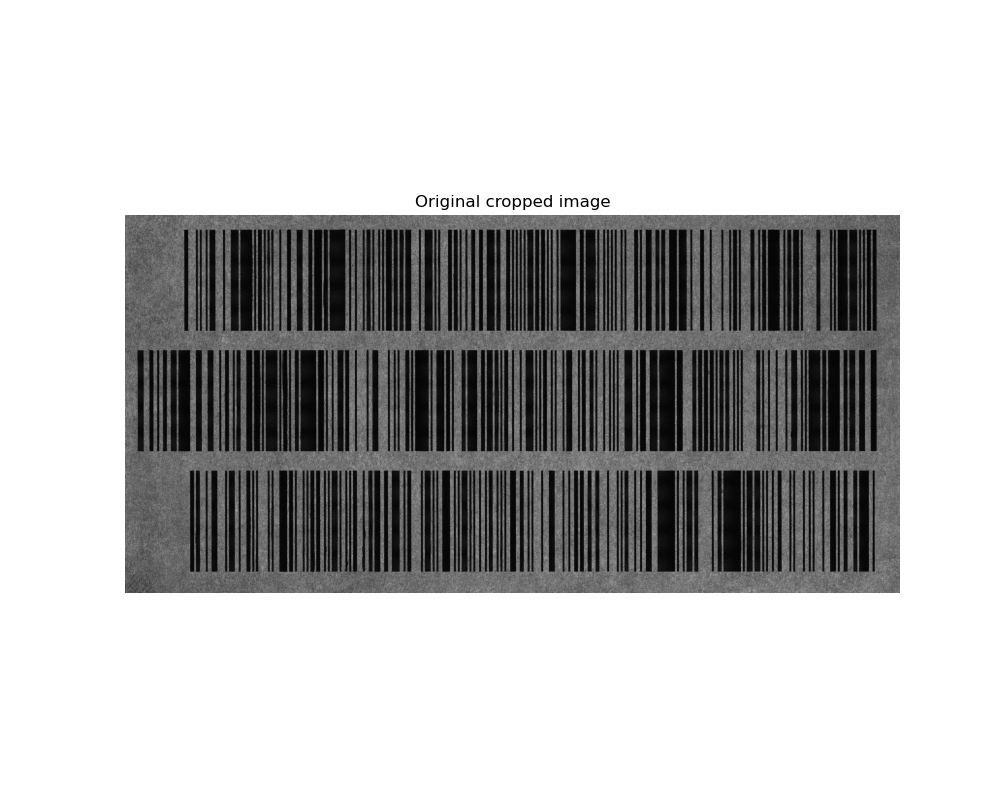

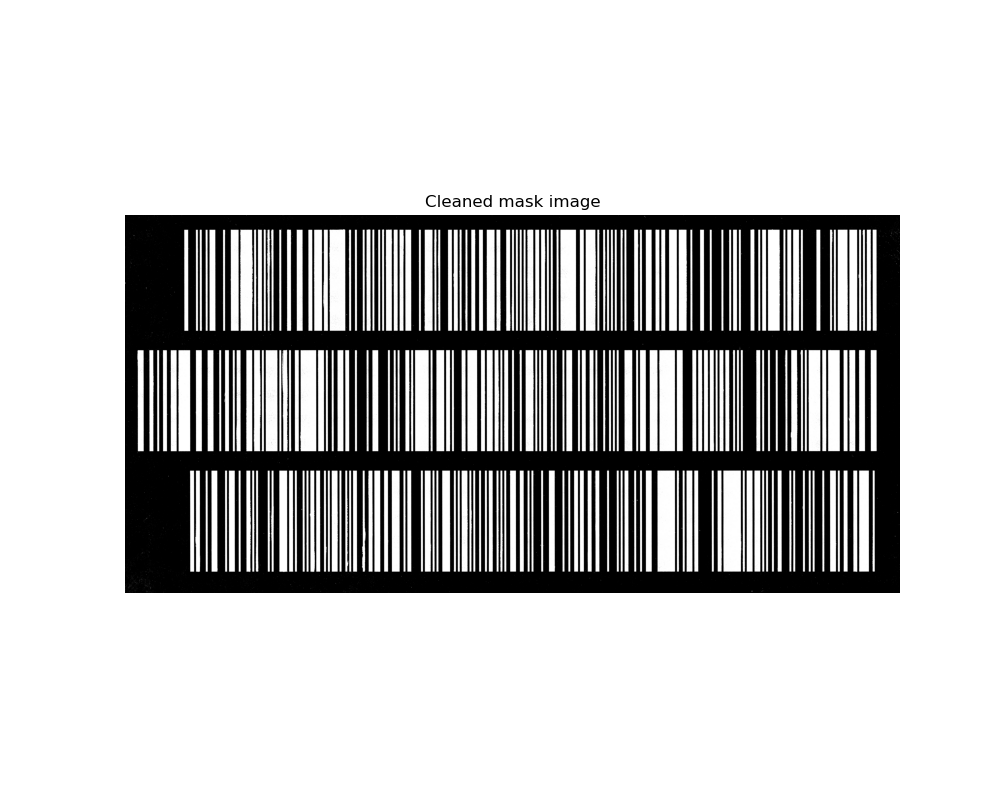

In [5]:
clean_mask = create_clean_binary_mask(subimg, morph=False, otsu_fac=2)

show_image(subimg, 'Original cropped image', 0.2)
show_image(clean_mask, 'Cleaned mask image', 0.2)

In [6]:
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
min_area = (1/MM_PER_PIXEL_X * 0.25 ) * (1/MM_PER_PIXEL_Y * 13.0 ) * 0.25  # Adjust this depending on image characteristics
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
print("Valid contours:", len(valid_contours))

Valid contours: 285


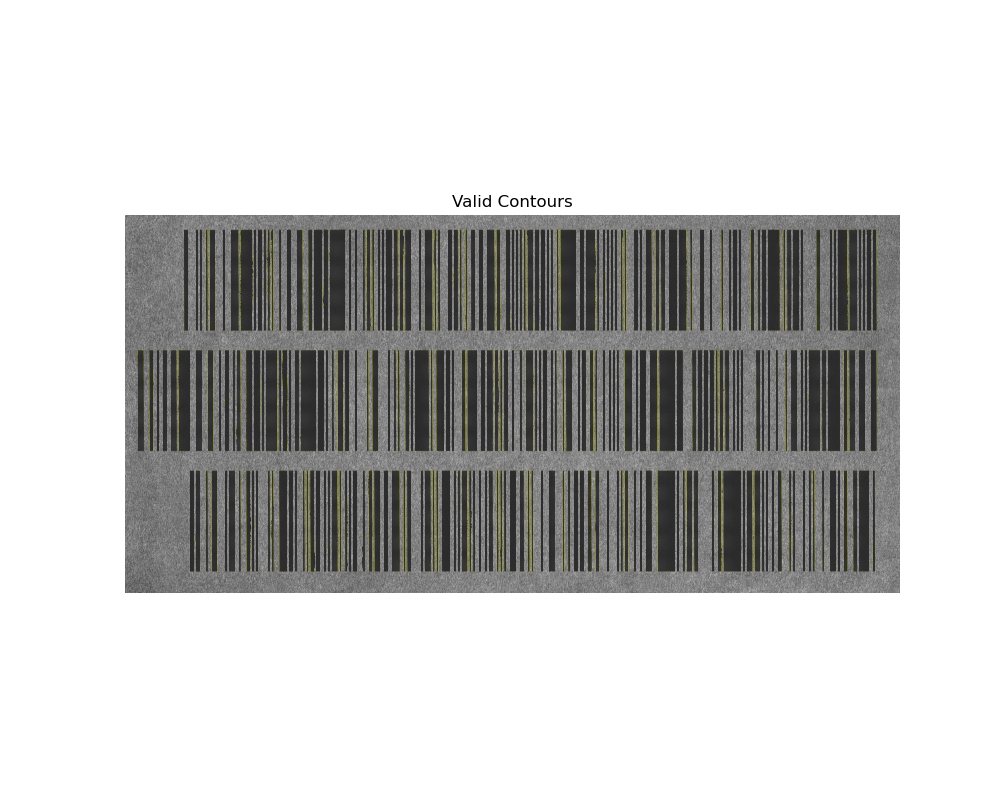

In [7]:
# 6. Draw the valid contours on a copy of the original image
output_image = cv2.cvtColor(subimg, cv2.COLOR_GRAY2RGB)
output_image_rect = cv2.cvtColor(subimg, cv2.COLOR_GRAY2RGB)

# Draw contours in bright green (0, 255, 0) with a thickness of 2
cv2.drawContours(output_image, valid_contours, -1, (255, 255, 0), 2)

show_image(output_image, 'Valid Contours', 0.5)

Image dims (23296, 47840, 3)
Contours dim 285
Valid slits found: 285


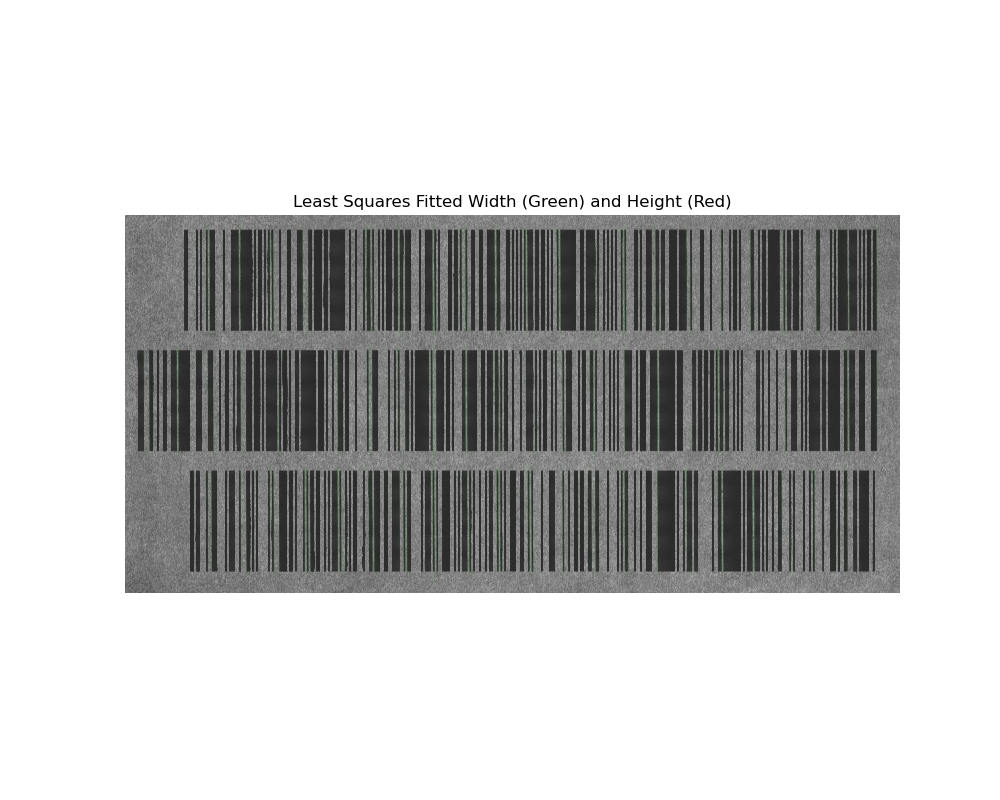

In [8]:
output_image, measured_slits = process_contours(subimg, valid_contours, MM_PER_PIXEL_X, MM_PER_PIXEL_Y)
print(f"Valid slits found: {len(measured_slits)}")
# Display the results
show_image(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB), 'Least Squares Fitted Width (Green) and Height (Red)', 0.5)

In [9]:
widths_err = [(slit["width"] - np.round(slit["width"]/0.25) * 0.25  ) * 1000  for slit in measured_slits]
heights_err = [(slit["height"] - 13.0 ) * 1000 for slit in measured_slits]

count_w = np.sum(np.abs(np.array(widths_err)) <= 10)
count_h = np.sum(np.abs(np.array(heights_err)) <= 50)


print("#widths:", len(widths_err))
print("widths_err <= 10um:", count_w, count_w/len(widths_err) * 100, "%")

print("#heights:", len(heights_err))
print("heights_err <= 50um:", count_h, count_h/len(heights_err) * 100, "%")

#widths: 285
widths_err <= 10um: 278 97.54385964912281 %
#heights: 285
heights_err <= 50um: 285 100.0 %


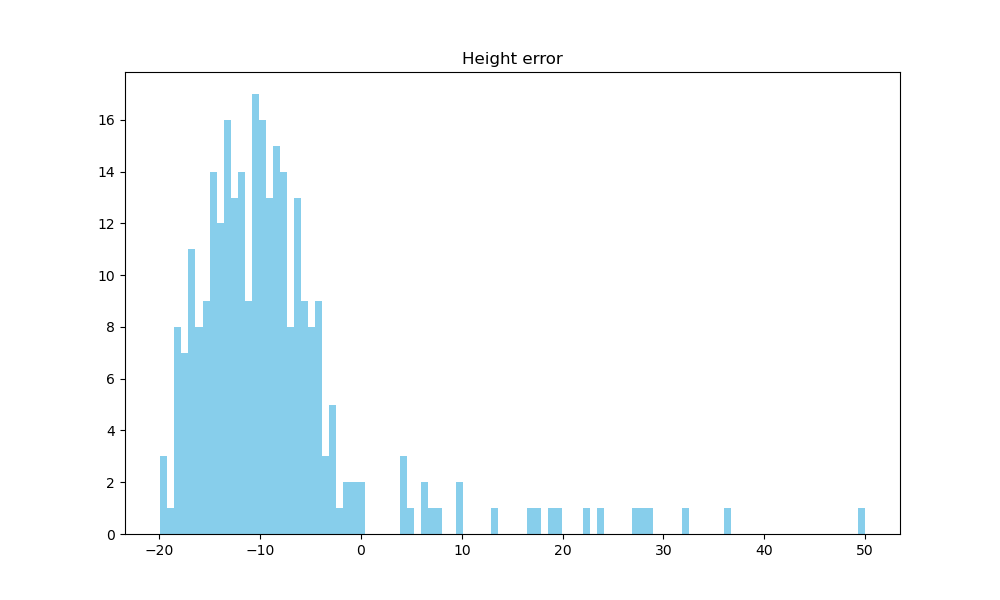

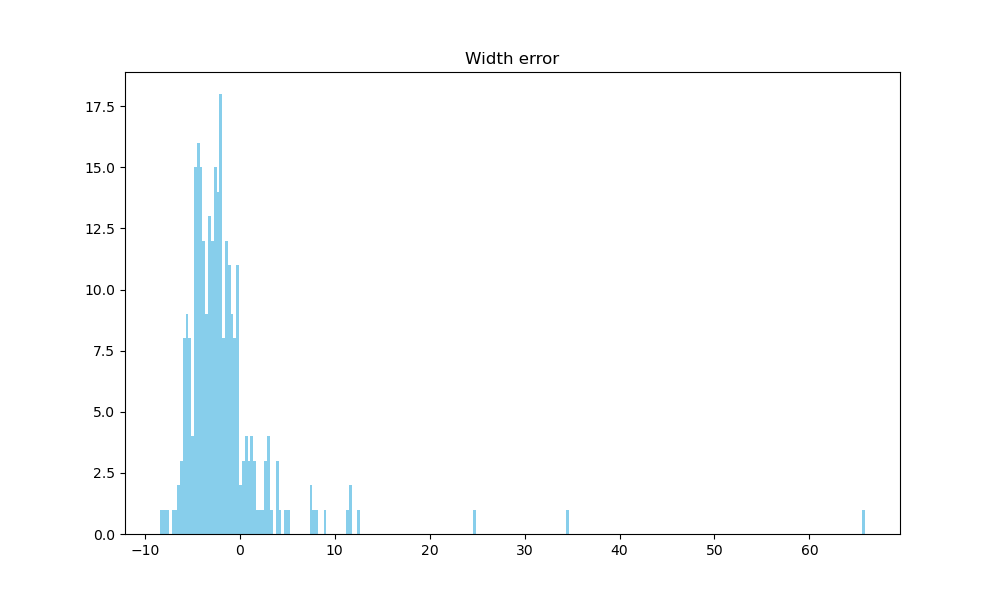

In [10]:
plt.figure(figsize=(10, 6))
plt.title("Height error")
plt.hist(heights_err, bins=100, color='skyblue')
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Width error")
plt.hist(widths_err, bins=250, color='skyblue')
plt.show()

In [11]:
# Create a dictionary to hold lists of errors grouped by their nominal target
error_by_nominal = {}

# 1. Group the errors
for slit in measured_slits:
    w = slit["width"]
    
    # Calculate target (nominal) width in mm
    nominal = np.round(w / 0.25) * 0.25 
    
    # Calculate error in micrometers (um)
    # Positive means the slit is too wide; Negative means it's too narrow
    error_um = (w - nominal) * 1000 
    
    # Add it to the corresponding group in the dictionary
    if nominal not in error_by_nominal:
        error_by_nominal[nominal] = []
        
    error_by_nominal[nominal].append(error_um)


# 2. Calculate and print the stats
print("--- Width Deviations by Target Size ---")

# Sort the dictionary keys so it prints from smallest nominal slit to largest
for nominal in sorted(error_by_nominal.keys()):
    errors = error_by_nominal[nominal]
    
    # Calculate min, max, and other useful metrics
    min_err = min(errors)
    max_err = max(errors)
    mean_err = np.mean(errors)
    count = len(errors)
    
    # Convert nominal mm to um for a cleaner display (e.g., 0.25mm -> 250µm)
    nominal_um = int(nominal * 1000)
    
    print(f"Target: {nominal_um} µm | Sample Size: {count} slits")
    
    # Using ":+.1f" forces Python to print the +/- sign, which is vital for error analysis
    print(f"  Min Deviation: {min_err:+.1f} µm")
    print(f"  Max Deviation: {max_err:+.1f} µm")
    print(f"  Avg Deviation: {mean_err:+.1f} µm")
    print("-" * 40)

--- Width Deviations by Target Size ---
Target: 250 µm | Sample Size: 142 slits
  Min Deviation: -7.8 µm
  Max Deviation: +12.4 µm
  Avg Deviation: -2.8 µm
----------------------------------------
Target: 500 µm | Sample Size: 75 slits
  Min Deviation: -8.4 µm
  Max Deviation: +65.8 µm
  Avg Deviation: -1.0 µm
----------------------------------------
Target: 750 µm | Sample Size: 37 slits
  Min Deviation: -5.5 µm
  Max Deviation: +34.5 µm
  Avg Deviation: -0.3 µm
----------------------------------------
Target: 1000 µm | Sample Size: 14 slits
  Min Deviation: -3.5 µm
  Max Deviation: +4.1 µm
  Avg Deviation: -0.9 µm
----------------------------------------
Target: 1250 µm | Sample Size: 4 slits
  Min Deviation: -2.1 µm
  Max Deviation: +9.0 µm
  Avg Deviation: +3.4 µm
----------------------------------------
Target: 1500 µm | Sample Size: 6 slits
  Min Deviation: -5.3 µm
  Max Deviation: +24.6 µm
  Avg Deviation: +3.4 µm
----------------------------------------
Target: 1750 µm | Sample

* The Red Line (Median): This represents your Accuracy (Bias). If the red lines are consistently above the green zero-line, your cutting tool/laser is systematically cutting too wide.

* The Blue Box (Interquartile Range): This contains the middle 50% of your slits and represents your Precision (Variance). A taller box means the manufacturing process for that specific size is highly variable.

* The Whiskers & Dots: The dots outside the whiskers are your statistical outliers — these are the specific slits that suffered from a sudden mechanical jump, a piece of debris, or a severe optical artifact.

C:\Users\Utente\AppData\Local\Temp\ipykernel_26128\1112447315.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


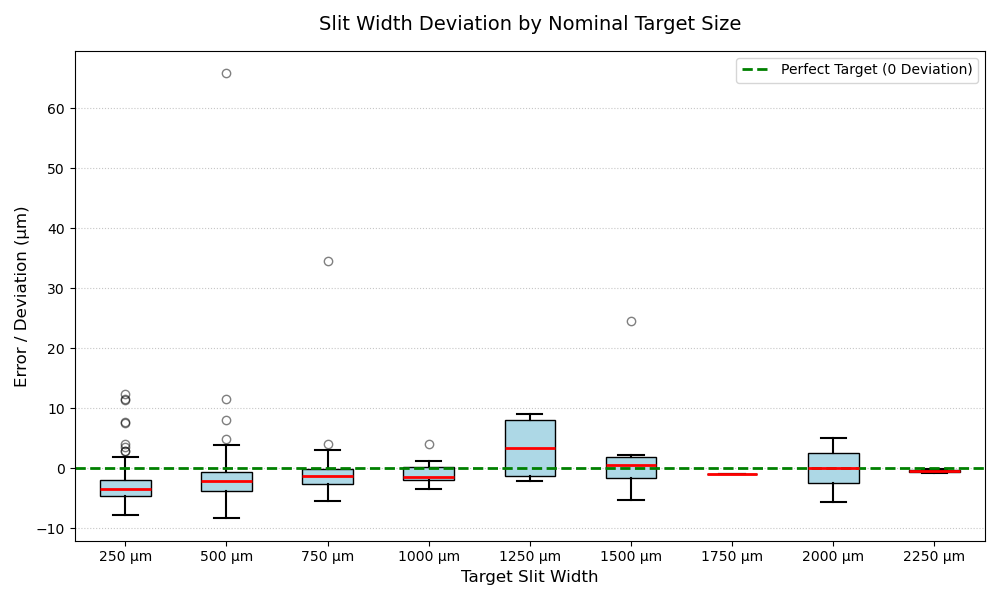

In [12]:
# 1. Prepare the data
# Sort the nominal sizes so they appear in ascending order left-to-right on the plot
sorted_nominals = sorted(error_by_nominal.keys())

# Extract the list of errors corresponding to each sorted nominal size
data_to_plot = [error_by_nominal[nominal] for nominal in sorted_nominals]

# Create X-axis labels (convert mm to µm for a cleaner look)
labels = [f"{int(nom * 1000)} µm" for nom in sorted_nominals]

# 2. Set up the figure
plt.figure(figsize=(10, 6))

# 3. Create the Boxplot
# patch_artist=True allows us to fill the boxes with color
plt.boxplot(
    data_to_plot, 
    labels=labels, 
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', color='black', alpha=0.5) # Style for the outlier dots
)

# 4. Add the Critical Reference Line
# Draw a dashed green line at Y=0 so you can instantly see the target deviation
plt.axhline(0, color='green', linestyle='--', linewidth=2, label='Perfect Target (0 Deviation)')

# 5. Format the plot
plt.title('Slit Width Deviation by Nominal Target Size', fontsize=14, pad=15)
plt.xlabel('Target Slit Width', fontsize=12)
plt.ylabel('Error / Deviation (µm)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [13]:
#Read DXF file (same Mask sector, same orientation)

nominal_measurements = process_dxf("F:/LEM-X/Masks/Metrology/mask_050_1040x17_20260129_ELXDIM_250um_Kirana_sector_10x5cm.dxf")
# Example Output
for i, slit in enumerate(nominal_measurements[:3]):
    print(f"DXF Slit {i+1}: Center={slit['center']}, Width={slit['width']:.3f}mm, Height={slit['height']:.3f}mm")

Found 285 nominal slits in the DXF.
DXF Slit 1: Center=(np.float64(35.125), np.float64(108.5)), Width=0.750mm, Height=13.000mm
DXF Slit 2: Center=(np.float64(36.5), np.float64(108.5)), Width=0.500mm, Height=13.000mm
DXF Slit 3: Center=(np.float64(37.375), np.float64(108.5)), Width=0.250mm, Height=13.000mm


In [14]:
# --- Executing the Matching Phase ---

# Assuming 'physical_measurements' and 'nominal_measurements' are lists of dicts
# generated from Phase A and Phase B in the previous steps.

# We set the tolerance to roughly half the height of a slit. 
# Based on your DXF, slits are 13mm tall, so a 2mm tolerance is very safe.
TOLERANCE_MM = 2.0 

# Sort the Image data (Y goes down)
sorted_physical = sort_grid(measured_slits, y_direction='down', row_tolerance=TOLERANCE_MM)

# Sort the DXF data (Y goes up)
sorted_nominal = sort_grid(nominal_measurements, y_direction='up', row_tolerance=TOLERANCE_MM)

# Ensure we found the same number of slits before comparing
if len(sorted_physical) != len(sorted_nominal):
    print(f"WARNING: Count mismatch! Found {len(sorted_physical)} in image vs {len(sorted_nominal)} in DXF.")
    # In a production script, you'd want to handle missing slits here.


errors = []

# --- Compare and Calculate Deltas ---
for i in range(min(len(sorted_physical), len(sorted_nominal))):
    meas = sorted_physical[i]
    nom = sorted_nominal[i]
    
    # Calculate dimensional deviation (kerf/melting error)
    width_error = meas['width'] - nom['width']
    height_error = meas['height'] - nom['height']
    x_error = meas["center"][0] - nom["center"][0]
    
    # Calculate spatial offset (how far the center shifted during cutting)
    # Note: To calculate absolute shift, both coordinate systems would need to be perfectly registered first.
    # But checking internal dimensions is perfectly valid.

    errors.append({
         "width_error":    width_error,
         "height_error":   height_error,
         "x_error":    x_error        
    })
    
#    print(f"Slit {i+1}:")
#    print(f"  Target  : W={nom['width']:.3f}mm, L={nom['height']:.3f}mm")
#    print(f"  Measured: W={meas['width']:.3f}mm, L={meas['height']:.3f}mm")
#    print(f"  Delta   : Width Error = {width_error:+.4f}mm | Length Error = {height_error:+.4f}mm | X Error = {x_error:+.4f}mm\n")

In [15]:
# 1. Extract the (x, y) tuples into standard N x 2 numpy arrays
pts_phys = np.array([item["center"] for item in sorted_physical], dtype=np.float32)
pts_nom  = np.array([item["center"] for item in sorted_nominal], dtype=np.float32)

# 2. Find the optimal transformation matrix
# transform_matrix will map physical points -> nominal points
transform_matrix, inliers = cv2.estimateAffinePartial2D(pts_phys, pts_nom)

if transform_matrix is not None:
    print("Transformation Matrix:\n", transform_matrix)
else:
    print("Failed to find a valid transformation.")

# 2.Transform sorted_physical
# 1. Reshape your (N, 2) array to (N, 1, 2) for OpenCV
pts_phys_reshaped = pts_phys.reshape(-1, 1, 2)

# 2. Apply the 2x3 transformation matrix
aligned_pts_reshaped = cv2.transform(pts_phys_reshaped, transform_matrix)

# 3. Reshape back to a standard (N, 2) array
aligned_pts = aligned_pts_reshaped.reshape(-1, 2)


aligned_physical = []
residual_errors = []

for i in range(len(sorted_physical)):
    # 1. Extract the new aligned coordinates and the nominal target
    new_x, new_y = aligned_pts[i]
    nom_x, nom_y = sorted_nominal[i]["center"]
    
    # 2. Calculate the exact difference (Error)
    dx = new_x - nom_x
    dy = new_y - nom_y
    euclidean_dist = np.hypot(dx, dy)
    
    # 3. Store the new aligned data
    aligned_physical.append({
        "center": (new_x, new_y),
        "width": sorted_physical[i]["width"],
        "height": sorted_physical[i]["height"]
    })
    
    # 4. Store the errors for statistical analysis later
    residual_errors.append({
        "x_error": dx,
        "y_error": dy,
        "total_offset": euclidean_dist
    })

# Quick readout of the worst-case scenario
max_error = max(item["total_offset"] for item in residual_errors)
print(f"Maximum remaining positional error: {max_error:.4f} units")

Transformation Matrix:
 [[ 1.00001582e+00 -1.59498444e-04  3.31015438e+01]
 [ 1.59498444e-04  1.00001582e+00  8.46041940e+01]]
Maximum remaining positional error: 31.0307 units


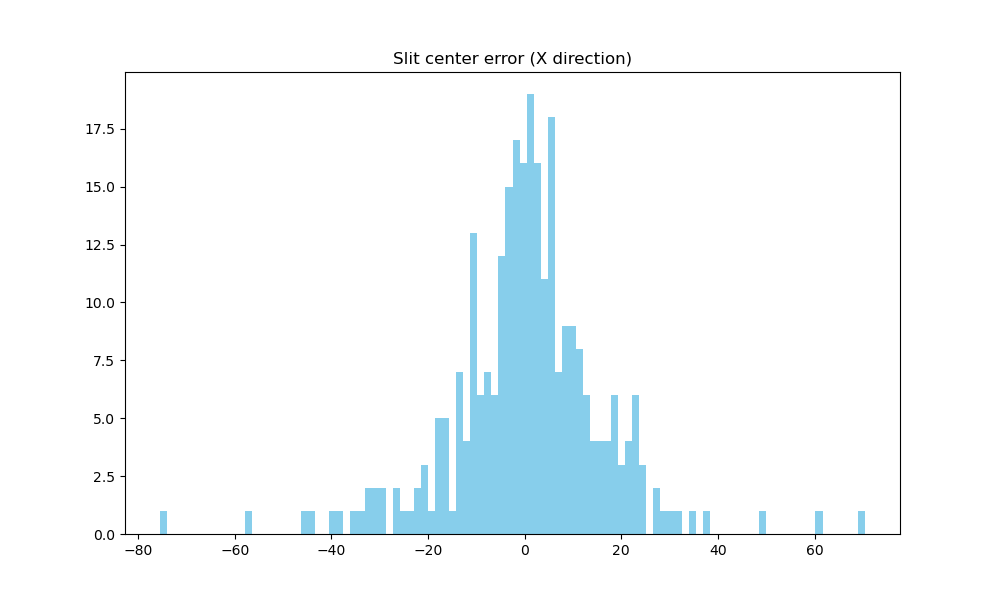

In [16]:
x_error = [item["x_error"]*1000 for item in residual_errors]
x_pos = [item["center"][0] for item in aligned_physical]
plt.figure(figsize=(10, 6))
plt.title("Slit center error (X direction)")
plt.hist(x_error , bins=100, color='skyblue')
plt.show()

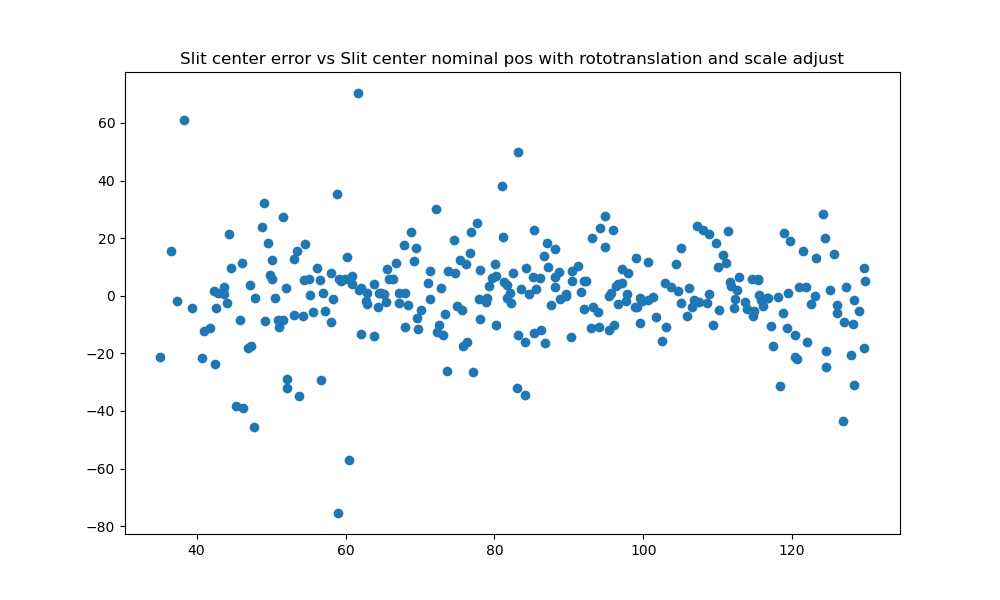

In [17]:
plt.figure(figsize=(10, 6))
plt.title("Slit center error vs Slit center nominal pos with rototranslation and scale adjust")
plt.scatter(x_pos, x_error)
plt.show()

In [18]:
#this is a rigid body fit (no scaling)

from skimage.transform import EuclideanTransform
from skimage.measure import ransac

# 1. Format your points as standard (N, 2) numpy arrays
pts_phys = np.array([item["center"] for item in sorted_physical], dtype=np.float32)
pts_nom  = np.array([item["center"] for item in sorted_nominal], dtype=np.float32)

# 2. Estimate the pure Rigid Transform (Scale is strictly 1.0)
# residual_threshold is the max pixel/unit error to be considered a "good" match
model, inliers = ransac((pts_phys, pts_nom), EuclideanTransform, 
                        min_samples=2, residual_threshold=2.0, max_trials=100)

if model is not None:
    # This returns a 3x3 homogeneous transformation matrix
    matrix_3x3 = model.params
    
    # You can easily extract the exact rotation angle and translation
    rotation_rads = model.rotation
    tx, ty = model.translation
    
    print(f"Rotation (degrees): {np.degrees(rotation_rads):.4f}")
    print(f"Translation: X={tx:.4f}, Y={ty:.4f}")
else:
    print("Failed to find a valid transformation.")

aligned_pts_rigid = model(pts_phys)

aligned_physical = []
residual_errors = []
for i in range(len(sorted_physical)):
    # 1. Extract the new aligned coordinates and the nominal target
    new_x, new_y = aligned_pts_rigid[i]
    nom_x, nom_y = sorted_nominal[i]["center"]
    
    # 2. Calculate the exact difference (Error)
    dx = new_x - nom_x
    dy = new_y - nom_y
    euclidean_dist = np.hypot(dx, dy)
    
    # 3. Store the new aligned data
    aligned_physical.append({
        "center": (new_x, new_y),
        "width": sorted_physical[i]["width"],
        "height": sorted_physical[i]["height"]
    })
    
    # 4. Store the errors for statistical analysis later
    residual_errors.append({
        "x_error": dx,
        "y_error": dy,
        "total_offset": euclidean_dist
    })

# Quick readout of the worst-case scenario
max_error = max(item["total_offset"] for item in residual_errors)
print(f"Maximum remaining positional error: {max_error:.4f} units")

Rotation (degrees): 0.0091
Translation: X=33.1023, Y=84.6046
Maximum remaining positional error: 31.0304 units


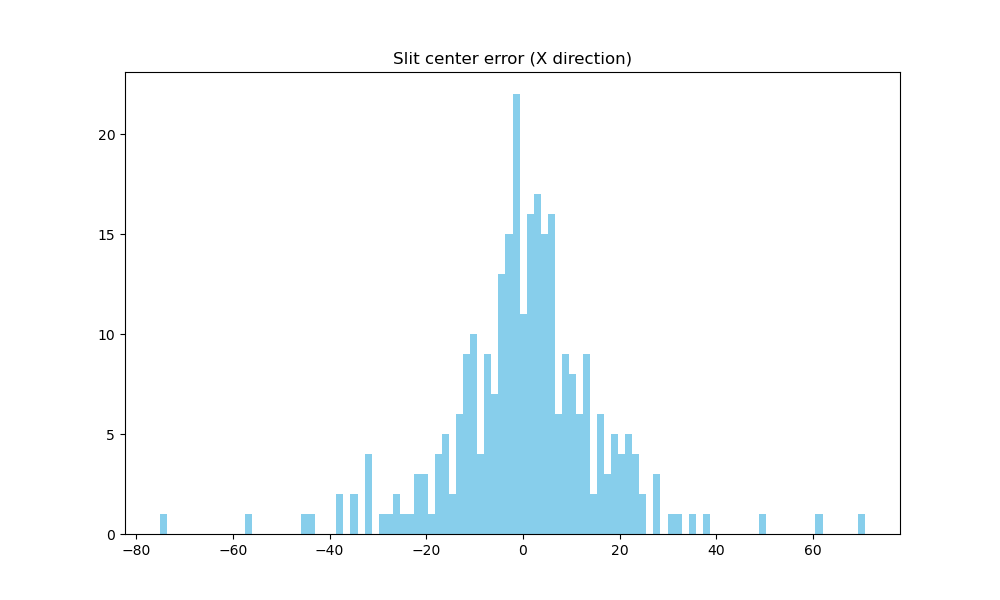

In [19]:
x_error = [item["x_error"]*1000 for item in residual_errors]
x_pos = [item["center"][0] for item in aligned_physical]
plt.figure(figsize=(10, 6))
plt.title("Slit center error (X direction)")
plt.hist(x_error , bins=100, color='skyblue')
plt.show()

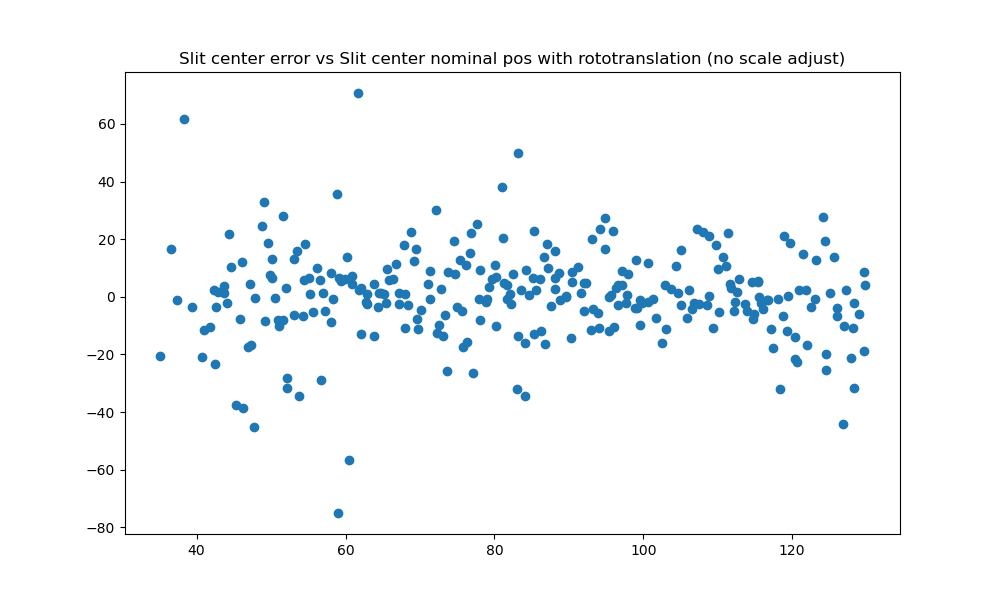

In [20]:
plt.figure(figsize=(10, 6))
plt.title("Slit center error vs Slit center nominal pos with rototranslation (no scale adjust)")
plt.scatter(x_pos, x_error)
plt.show()

In [21]:
# Define where the images will be saved
OUTPUT_DIR = os.path.join(PATH, "Error_Subimages_HUBER_v4")

# Call the function to save the top 10 error subimages with a 75-pixel margin
save_top_width_error_subimages(
    image=output_image, 
    measured_slits=sorted_physical, 
    dxf_slits=sorted_nominal, 
    res_x=MM_PER_PIXEL_X, 
    res_y=MM_PER_PIXEL_Y, 
    output_folder=OUTPUT_DIR, 
    top_n=10, 
    margin=75
)

Successfully generated and saved top 10 combined error subimages to 'F:/LEM-X/Masks/Metrology/Error_Subimages_HUBER_v4'.


In [22]:
opt_res_x, opt_res_y = calibrate_resolutions(
    sorted_physical, 
    sorted_nominal, 
    current_res_x=MM_PER_PIXEL_X, 
    current_res_y=MM_PER_PIXEL_Y
)

--- Calibration Results ---
Initial Res X: 0.002088558 mm/px
Optimal Res X: 0.002088591 mm/px
Error X:       0.0016 %
-------------------------
Initial Res Y: 0.002087800 mm/px
Optimal Res Y: 0.002087726 mm/px
Error Y:       0.0035 %
